# BASIC

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px

In [42]:
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic = pd.read_csv(url)
titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


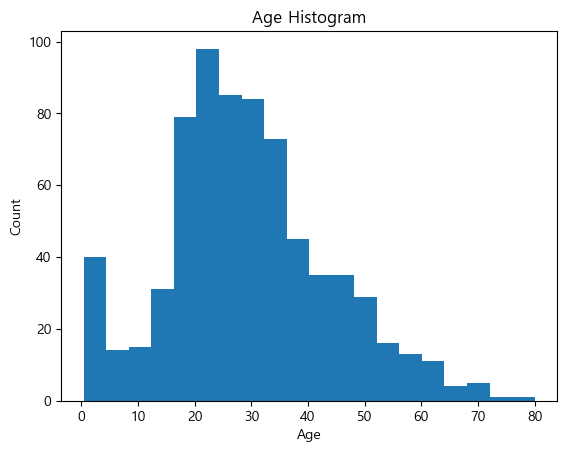

In [43]:
plt.hist(titanic["Age"].dropna(), bins=20)
plt.xlabel("Age")
plt.ylabel("Count")
plt.title("Age Histogram")
plt.show()

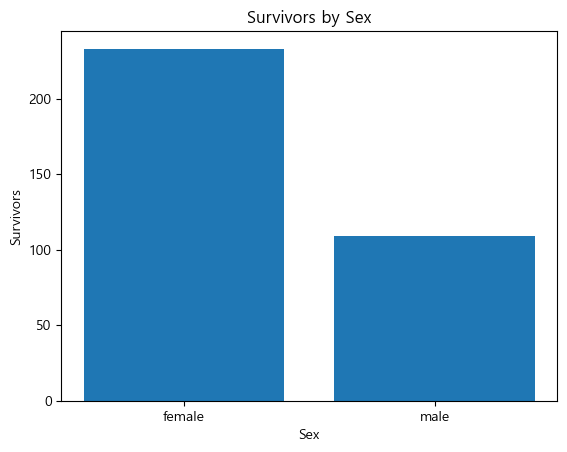

In [44]:
survived_by_sex = titanic[titanic["Survived"] == 1]["Sex"].value_counts()

plt.bar(survived_by_sex.index, survived_by_sex.values)
plt.xlabel("Sex")
plt.ylabel("Survivors")
plt.title("Survivors by Sex")
plt.show()

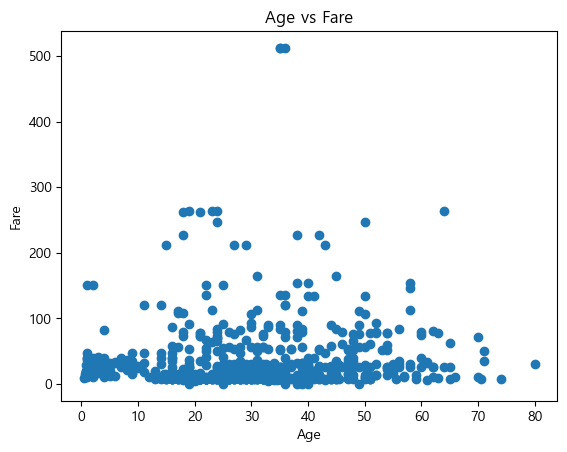

In [45]:
plt.scatter(titanic["Age"], titanic["Fare"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Age vs Fare")
plt.show()

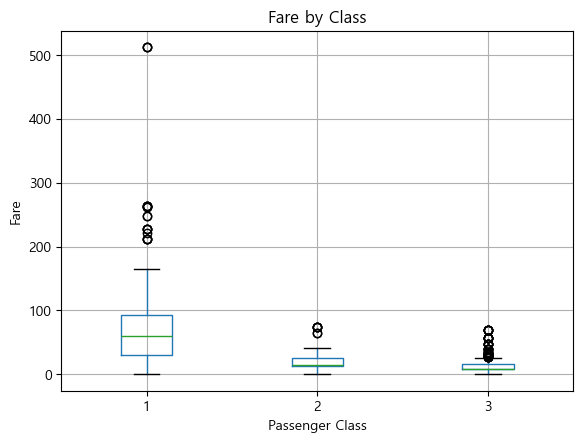

In [46]:
titanic.boxplot(column="Fare", by="Pclass")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.title("Fare by Class")
plt.suptitle("")
plt.show()

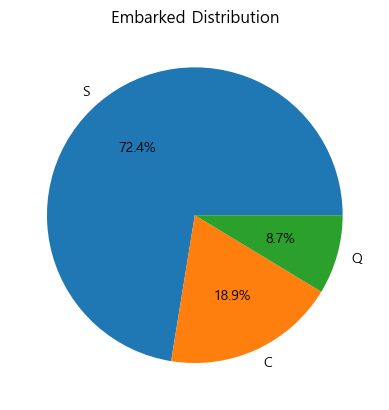

In [47]:
embarked_count = titanic["Embarked"].value_counts()

plt.pie(embarked_count.values, labels=embarked_count.index, autopct="%1.1f%%")
plt.title("Embarked Distribution")
plt.show()

In [48]:
imdb = pd.read_csv("imdb_top_1000.csv")
imdb.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [49]:
imdb.columns

Index(['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate',
       'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director',
       'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross'],
      dtype='str')

In [50]:
fig = px.histogram(imdb, x="IMDB_Rating", nbins=20, title="IMDB Rating Histogram")
fig.show()

In [51]:
fig = px.scatter(imdb, x="No_of_Votes", y="IMDB_Rating", title="No_of_Votes vs IMDB_Rating")
fig.show()

In [52]:
fig.write_html("imdb_scatter.html")

# APPLIED

In [53]:
import pandas as pd
import plotly.express as px

apt = pd.read_csv("seoul_apartment.csv")
apt.head()

,NO,시군구,번지,본번,부번,단지명,전용면적(㎡),계약년월,계약일,거래금액(만원),층,건축년도,도로명
0,1,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),94.51,200811,3,63000,6,2008,사직로8길 4
1,2,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),146.92,200810,10,97000,13,2008,사직로8길 4
2,3,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),146.92,200810,7,100000,1,2008,사직로8길 4
3,4,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),146.92,200810,1,95000,12,2008,사직로8길 4
4,5,서울특별시 종로구 사직동,9,9,0,광화문스페이스본(101동~105동),146.92,200809,26,95000,11,2008,사직로8길 4


In [54]:
apt.columns

Index(['NO', '시군구', '번지', '본번', '부번', '단지명', '전용면적(㎡)', '계약년월', '계약일',
       '거래금액(만원)', '층', '건축년도', '도로명'],
      dtype='str')

In [80]:
monthly_avg = apt.groupby("계약년월")["거래금액(만원)"].mean().reset_index()

fig = px.line(
    monthly_avg,
    x="계약년월",
    y="거래금액(만원)",
    title="월별 평균 가격"
)

fig.show()
fig.write_image("월별_평균_가격.png", width=1400, height=800, scale=2)

In [79]:
monthly_count = apt["계약년월"].value_counts().sort_index().reset_index()
monthly_count.columns = ["계약년월", "거래건수"]

fig = px.bar(
    monthly_count,
    x="계약년월",
    y="거래건수",
    title="월별 거래 건수"
)

fig.show()
fig.write_image("월별_거래_건수.png", width=1400, height=800, scale=2)

In [57]:
apt["구"] = apt["시군구"].str.split().str[1]

In [78]:
district_avg = apt.groupby("구")["거래금액(만원)"].mean().reset_index()

fig = px.bar(
    district_avg,
    x="거래금액(만원)",
    y="구",
    orientation="h",
    title="구별 평균 가격"
)

fig.show()
fig.write_image("구별_평균_가격.png", width=1400, height=800, scale=2)

In [59]:
apt["연도"] = apt["계약년월"].astype(str).str[:4].astype(int)

In [77]:
recent = apt[apt["연도"] >= apt["연도"].max() - 2]

year_avg = recent.groupby("연도")["거래금액(만원)"].mean().reset_index()

fig = px.line(
    year_avg,
    x="연도",
    y="거래금액(만원)",
    title="최근 3년 가격 추이"
)

fig.show()
fig.write_image("최근_3년_가격_추이.png", width=1400, height=800, scale=2)

In [61]:
fig.write_html("seoul_apartment.html")

# CHALLENGE

In [62]:
imdb_g = imdb.copy()

imdb_g["Genre"] = imdb_g["Genre"].str.split(",")

imdb_g = imdb_g.explode("Genre")

imdb_g["Genre"] = imdb_g["Genre"].str.strip()

In [76]:
genre_avg = imdb_g.groupby("Genre")["IMDB_Rating"].mean().reset_index()

fig = px.bar(
    genre_avg,
    x="Genre",
    y="IMDB_Rating",
    title="Average Rating by Genre"
)

fig.show()
fig.write_image("Average_Rating_by_Genre.png", width=1400, height=800, scale=2)

In [64]:
year_avg = imdb.groupby("Released_Year")["IMDB_Rating"].mean().reset_index()

In [65]:
year_avg["Released_Year"] = pd.to_numeric(
    year_avg["Released_Year"],
    errors="coerce"
)

year_avg = year_avg.dropna()

In [74]:
fig = px.scatter(
    year_avg,
    x="Released_Year",
    y="IMDB_Rating",
    title="Rating Trend by Year"
)

fig.show()
fig.write_image("Rating_Trend_by_Year.png", width=1400, height=800, scale=2)

In [67]:
imdb["Gross"] = imdb["Gross"].str.replace(",", "")

In [68]:
imdb["Gross"] = pd.to_numeric(
    imdb["Gross"],
    errors="coerce"
)

imdb = imdb.dropna(subset=["Gross"])

In [75]:
fig = px.scatter(
    imdb,
    x="Gross",
    y="IMDB_Rating",
    title="Gross vs Rating"
)

fig.show()
fig.write_image("Gross_vs_Rating.png", width=1400, height=800, scale=2)